In [1]:
import dill as pickle
import numpy as np
import matplotlib.pyplot as plt

use entropy of variances to measure how distributed the code is for different angles
drop/out of high variance cells to see if we can still decode the angles? - distribution of prediction accuracy
compare the coefficients in dot product with less crossvalidated - fewer overlapping points

In [2]:
# lad in coef
LDA_path = r"Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\models\LDA_fr_excl_prox_15cm\good\experimental_conditions\all\shelter_only\good_shelter_only_LDA_prediction_coef.pkl"
with open(LDA_path, "rb") as dill_file:
    prediction_coef_shelter_only = pickle.load(dill_file)
LDA_path = r"Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\models\LDA_fr_excl_prox_15cm\good\experimental_conditions\all\barrier_pre_flip\good_barrier_pre_flip_LDA_prediction_coef.pkl"
with open(LDA_path, "rb") as dill_file:
    prediction_coef_pre_bar = pickle.load(dill_file)
LDA_path = r"Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\models\LDA_fr_excl_prox_15cm\good\experimental_conditions\all\barrier_post_flip\good_barrier_post_flip_LDA_prediction_coef.pkl"
with open(LDA_path, "rb") as dill_file:
    prediction_coef_post_bar = pickle.load(dill_file)
n_cells = np.shape(prediction_coef_shelter_only['hdir'])[1]

Text(0.5, 1.0, 'cluster 317')

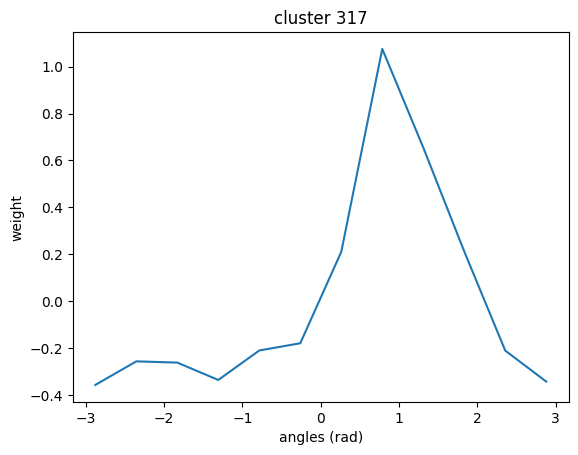

In [69]:
'''an example cluster's weights'''
cluster_Ids = np.load(r"Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\good_cluster_Ids.npy")
angle = 'h_bar_north_a' # 'h_bar_south_a', 'hdir', 'hsa'
peak_weight = np.argsort(np.var(prediction_coef_pre_bar[angle], axis = 0))
clu_choice = peak_weight[-10]
# clu_choice = int(np.where(cluster_Ids == 109)[0])
bin_angles = np.linspace(-np.pi, np.pi, 13)
bin_angle_center = np.sort(np.append([-np.pi, np.pi], [bin_angles[:-1] + (np.mean(np.diff(bin_angles)) / 2)]))
plt.plot(bin_angle_center[1:-1],prediction_coef_pre_bar[angle][:,clu_choice])
plt.ylabel('weight')
plt.xlabel('angles (rad)')
plt.title('cluster '+str(cluster_Ids[clu_choice]))

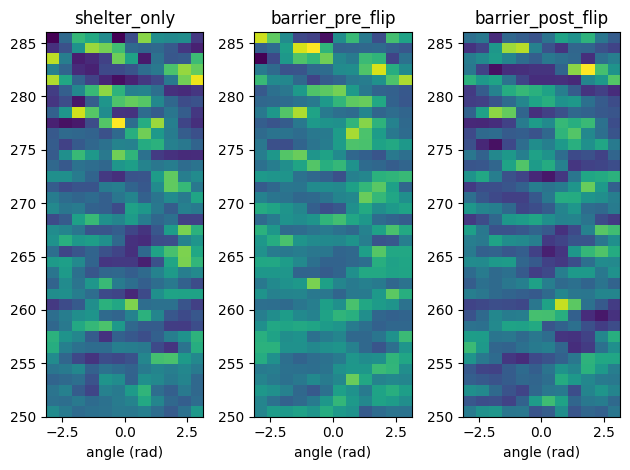

In [53]:
'''a look at the coefficients with the greatest variance'''
fig, axs = plt.subplots(1,3)
angle = 'h_bar_north_a' # 'h_bar_south_a', 'hdir', 'hsa'
peak_weight = np.argsort(np.var(prediction_coef_pre_bar[angle], axis = 0))
axs[0].imshow(prediction_coef_shelter_only[angle][:,peak_weight].T,aspect = 'auto',extent = [-np.pi,np.pi,n_cells,0])
axs[0].set_title('shelter_only')
axs[1].imshow(prediction_coef_pre_bar[angle][:,peak_weight].T,aspect = 'auto',extent = [-np.pi,np.pi,n_cells,0])
axs[1].set_title('barrier_pre_flip')
axs[2].imshow(prediction_coef_post_bar[angle][:,peak_weight].T,aspect = 'auto',extent = [-np.pi,np.pi,n_cells,0])
axs[2].set_title('barrier_post_flip')

for i in np.arange(3):
    axs[i].set_ylim((250,286))
    axs[i].set_xlabel('angle (rad)')
plt.tight_layout()

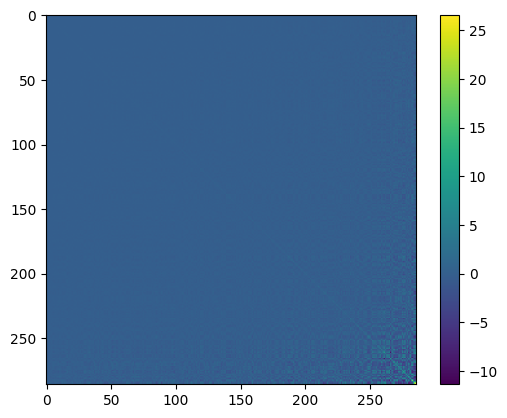

In [36]:
'''a look at the dot product between coefficients'''
plt.imshow(np.dot(prediction_coef_shelter_only['hdir'][:,peak_weight].T,prediction_coef_shelter_only['hdir'][:,peak_weight]))
plt.colorbar()
# plt.plot(np.dot(prediction_coef_shelter_only['hdir'].T,prediction_coef_shelter_only['hdir']))

Text(0.5, 1.0, 'hsa')

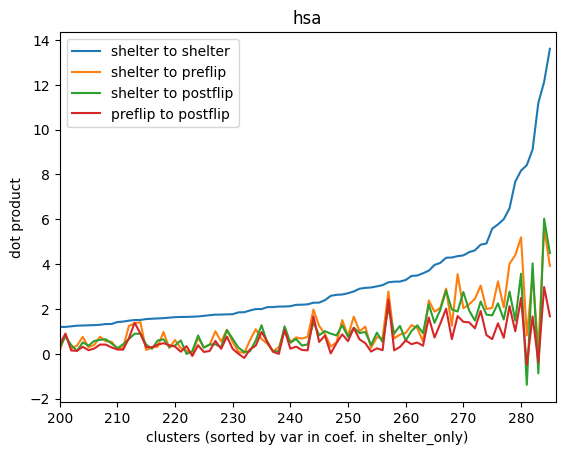

In [57]:
'''a look at the dot product between coefficients sorted by variance'''
angle = 'hsa' # 'h_bar_south_a', 'hdir', 'hsa'
peak_weight = np.argsort(np.var(prediction_coef_shelter_only[angle], axis = 0))
d_prod = np.empty(286)
for i in np.arange(286):
    d_prod[i] = np.dot(prediction_coef_shelter_only[angle][:,i], prediction_coef_shelter_only[angle][:,i])
plt.plot(d_prod[peak_weight])
for i in np.arange(286):
    d_prod[i] = np.dot(prediction_coef_shelter_only[angle][:,i], prediction_coef_pre_bar[angle][:,i])
plt.plot(d_prod[peak_weight])
for i in np.arange(286):
    d_prod[i] = np.dot(prediction_coef_shelter_only[angle][:,i], prediction_coef_post_bar[angle][:,i])
plt.plot(d_prod[peak_weight])
for i in np.arange(286):
    d_prod[i] = np.dot(prediction_coef_pre_bar[angle][:,i], prediction_coef_post_bar[angle][:,i])
plt.plot(d_prod[peak_weight])
plt.legend(['shelter to shelter','shelter to preflip','shelter to postflip', 'preflip to postflip'])
plt.xlim((200,286))
plt.xlabel('clusters (sorted by var in coef. in shelter_only)')
plt.ylabel('dot product')
plt.title(angle)

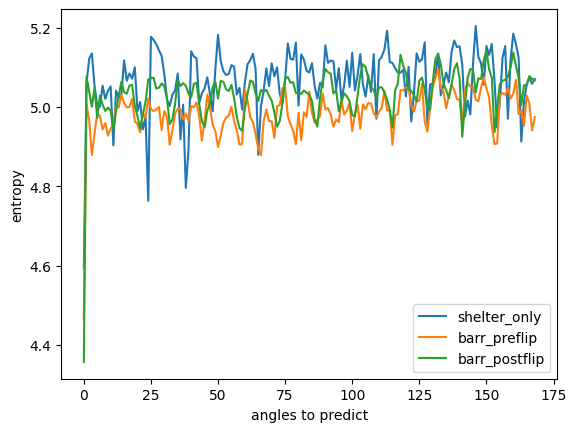

In [42]:
'''a quick look at entropy'''
from scipy.stats import entropy
all_angles = prediction_coef_shelter_only.keys()#['hdir','hsa','h_bar_north_a','h_bar_south_a']
var_weight = np.empty((3,len(all_angles)))
for i,angle in enumerate(all_angles):
    var = np.var(prediction_coef_shelter_only[angle], axis = 0)
    var_weight[0,i] = entropy(var/np.sum(var))
    var = np.var(prediction_coef_pre_bar[angle], axis = 0)
    var_weight[1,i] = entropy(var/np.sum(var))
    var = np.var(prediction_coef_post_bar[angle], axis = 0)
    var_weight[2,i] = entropy(var/np.sum(var))
plt.plot(var_weight.T)
plt.ylabel('entropy')
plt.xlabel('angles to predict')
plt.legend(['shelter_only','barr_preflip','barr_postflip'])

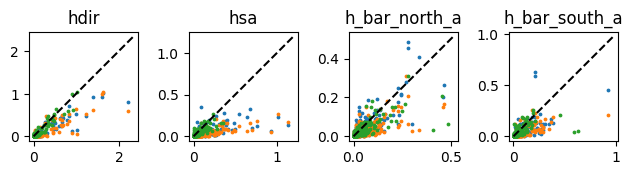

In [93]:
'''a look at coefficient variance across conditions'''
fig, axs = plt.subplots(1,4)
fig.set_figheight(15)
all_angles = ['hdir','hsa','h_bar_north_a','h_bar_south_a']
for i,angle in enumerate(all_angles):
    # peak_weight_shelt = np.amax(prediction_coef_shelter_only[angle], axis = 0)
    # peak_weight_pre = np.amax(prediction_coef_pre_bar[angle], axis = 0)
    # peak_weight_post = np.amax(prediction_coef_post_bar[angle], axis = 0)
    var_weight_shelt = np.var(prediction_coef_shelter_only[angle], axis = 0)
    var_weight_pre = np.var(prediction_coef_pre_bar[angle], axis = 0)
    var_weight_post = np.var(prediction_coef_post_bar[angle], axis = 0)
    axs[i].scatter(var_weight_shelt,var_weight_pre,s=3)
    axs[i].scatter(var_weight_shelt,var_weight_post,s=3)
    axs[i].scatter(var_weight_pre,var_weight_post,s=3)
    axs[i].plot([0,np.amax(np.array(axs[i].get_xlim(),axs[i].get_ylim()))],[0,np.amax(np.array(axs[i].get_xlim(),axs[i].get_ylim()))],'--k')
    axs[i].set_title(angle)
    axs[i].set_aspect('equal','box')
plt.tight_layout()

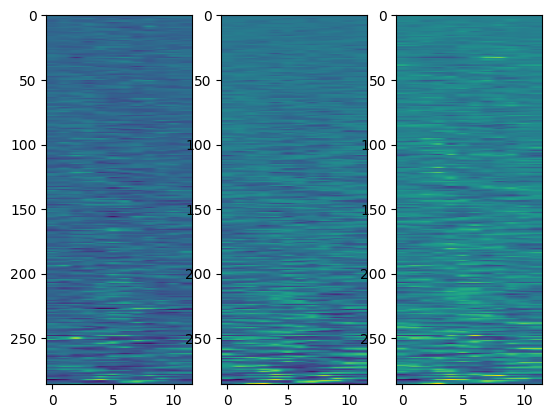

In [100]:
'''a look at all coefficients'''
angle = 'hsa'
fig, axs = plt.subplots(1,3)
peak_weight = np.amax(prediction_coef_pre_bar[angle], axis = 0)
axs[0].imshow(prediction_coef_shelter_only[angle][:,np.argsort(peak_weight)].T,aspect = 'auto')
axs[1].imshow(prediction_coef_pre_bar[angle][:,np.argsort(peak_weight)].T,aspect = 'auto')
axs[2].imshow(prediction_coef_post_bar[angle][:,np.argsort(peak_weight)].T,aspect = 'auto')

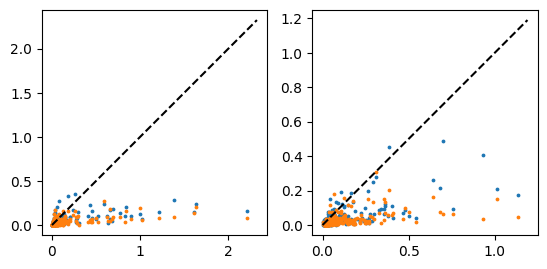

In [104]:
'''a look at coefficient variance across angles and conditions'''
fig, axs = plt.subplots(1,2)
i = 0
var_weight_shelt = np.var(prediction_coef_shelter_only['hdir'], axis = 0)
var_weight_pre = np.var(prediction_coef_pre_bar['h_bar_north_a'], axis = 0)
var_weight_post = np.var(prediction_coef_post_bar['h_bar_north_a'], axis = 0)
axs[i].scatter(var_weight_shelt,var_weight_pre,s=3)
axs[i].scatter(var_weight_shelt,var_weight_post,s=3)
axs[i].plot([0,np.amax(np.array(axs[i].get_xlim(),axs[i].get_ylim()))],[0,np.amax(np.array(axs[i].get_xlim(),axs[i].get_ylim()))],'--k')
axs[i].set_aspect('equal','box')

i = 1
var_weight_shelt = np.var(prediction_coef_shelter_only['hsa'], axis = 0)
var_weight_pre = np.var(prediction_coef_pre_bar['h_bar_north_a'], axis = 0)
var_weight_post = np.var(prediction_coef_post_bar['h_bar_north_a'], axis = 0)
axs[i].scatter(var_weight_shelt,var_weight_pre,s=3)
axs[i].scatter(var_weight_shelt,var_weight_post,s=3)
axs[i].plot([0,np.amax(np.array(axs[i].get_xlim(),axs[i].get_ylim()))],[0,np.amax(np.array(axs[i].get_xlim(),axs[i].get_ylim()))],'--k')
axs[i].set_aspect('equal','box')

Let's look at dropout prediction acuracy

In [14]:
import matplotlib.pyplot as plt
import dill as pickle
import numpy as np

In [15]:
LDA_path = r"W:\branco\Laurence\JAL008\JAL008_empty_shelter2_2024_04_22T10_51_22\processed_data\models\LDA_fr_excl_prox_15cm\good\experimental_conditions\all\pre_shelter\good_pre_shelter_LDA_prediction_accuracy.pkl"
with open(LDA_path, "rb") as dill_file:
    pa_shelt = pickle.load(dill_file)
LDA_path = r"W:\branco\Laurence\JAL008\JAL008_empty_shelter2_2024_04_22T10_51_22\processed_data\models\LDA_fr_excl_prox_15cm\good\experimental_conditions\all\pre_shelter\good_pre_shelter_LDA_dropout_pa.pkl"
with open(LDA_path, "rb") as dill_file:
    dropout_pa_shelt = pickle.load(dill_file)
LDA_path = r"W:\branco\Laurence\JAL008\JAL008_empty_shelter2_2024_04_22T10_51_22\processed_data\models\LDA_fr_excl_prox_15cm\good\experimental_conditions\all\pre_shelter\good_pre_shelter_LDA_prediction_coef.pkl"
with open(LDA_path, "rb") as dill_file:
    coef_shelt = pickle.load(dill_file)

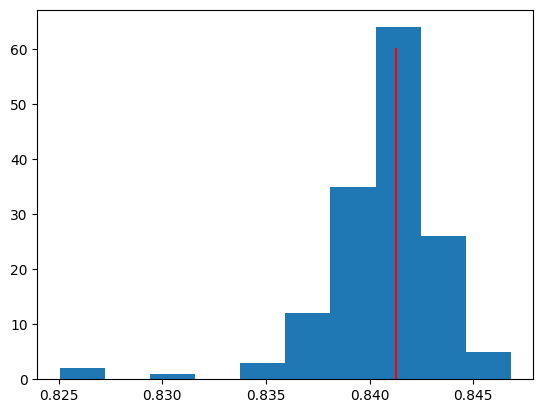

In [11]:
'''a histogram of prediction accuracy for each dropout - in red is the full model'''

plt.hist(dropout_pa_shelt['hdir'])
plt.plot([pa_shelt['hdir'],pa_shelt['hdir']],[0,60],'r')

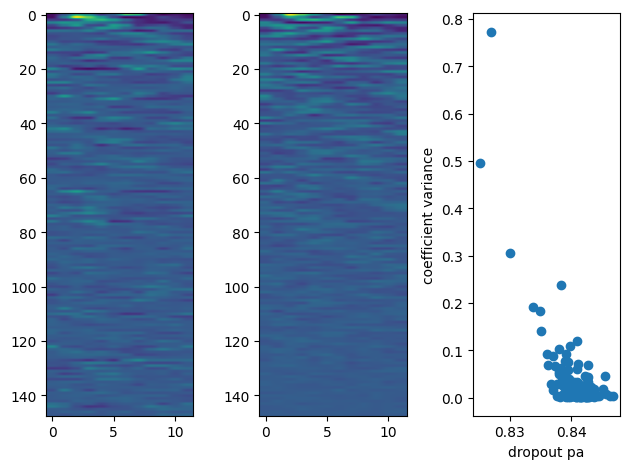

In [21]:
'''LDA coefficients sorted by dropout prediction accuracy'''
angle = 'hdir'
fig, axs = plt.subplots(1,3)
axs[0].imshow(coef_shelt[angle][:,np.argsort(dropout_pa_shelt[angle])].T,aspect = 'auto')
axs[1].imshow(coef_shelt[angle][:,np.flipud(np.argsort(np.var(coef_shelt[angle],axis = 0)))].T,aspect = 'auto')
axs[2].scatter(dropout_pa_shelt[angle],np.var(coef_shelt[angle],axis = 0))
axs[2].set_xlabel('dropout pa')
axs[2].set_ylabel('coefficient variance')
plt.tight_layout()